In [1]:
import numpy as np
from PIL import Image

box filter/mean filter
Python Imaging Library (PIL)
PIL.Image → used to open, process, and save images.
n = 1 means the code looks at pixels from -1 to +1 around the current pixel.

In [2]:
n = 1

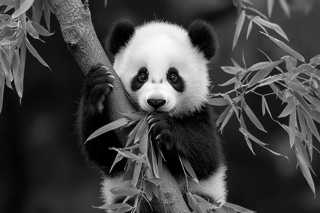

In [3]:
img = Image.open('images/panda.jpeg').convert('L').resize((640 // 2,426 // 2))
img

.covert('L')--> converts img into grayscale
so pixel has only 2 value, 0=black,255=white
.resize(640//2,426//2)--> img become 320*213
img--> shows image.
imgMat= show pixel values
dtype=np.uint8 means each pixel value is stored as an 8-bit unsigned integer, so values stay between 0 and 255.

In [4]:
imgMat = np.array(img, dtype=np.uint8)
imgMat

array([[107, 104, 104, ...,  67,  69,  70],
       [111, 112, 105, ...,  66,  68,  69],
       [111, 106, 106, ...,  65,  67,  67],
       ...,
       [ 16,  16,  15, ...,  31,  31,  31],
       [ 16,  16,  15, ...,  28,  28,  28],
       [ 16,  16,  15, ...,  27,  27,  27]], shape=(213, 320), dtype=uint8)

In [ ]:
def box_filter_pixel(i, j, mat):
    diff = range(-n, n + 1)

    pixel_sum = 0
    count = 0

    for dx in diff: #moves vertically around the current pixel.
        ni = i + dx #ni is the new row index after moving vertically by dx.

        if 0 <= ni < mat.shape[0]: #checks whether the row index ni is inside the image boundary. mat.shape[0] = number of rows
            for dy in diff: #moves horizontally around the current pixel.
                nj = j + dy #nj is the new column index after moving horizontally by dy.

                if 0 <= nj < mat.shape[1]: #checks whether the column index nj is inside the image boundary. mat.shape[1] = number of columns
                    pixel_sum += int(mat[ni][nj]) #adds the pixel value at (ni, nj) to the pixel_sum. int() is used to convert the pixel value to an integer for accurate summation.
                    count += 1 #increments the count of valid pixels that have been included in the sum.

    return pixel_sum // count #returns the average pixel value by dividing the total sum of pixel values (pixel_sum) by the count of valid pixels (count). The // operator performs integer division, ensuring that the result is an integer.

n=1, range = (-1,2) which gives (-1,0,1) 
pixel_sum stores the total sum of valid neighboring pixel values.
count stores how many pixels were included in the sum.

In [ ]:
# Create output image matrix
filtered = imgMat.copy() #copies the original image matrix (imgMat) to a new variable called filtered. This creates a new matrix that has the same dimensions and pixel values as the original image, allowing us to modify the filtered image without altering the original.
for i in range(imgMat.shape[0]): #iterates over each row index i of the image matrix (imgMat). imgMat.shape[0] gives the number of rows in the image, so this loop will run once for each row.
    for j in range(imgMat.shape[1]): #iterates over each column index j of the image matrix (imgMat). imgMat.shape[1] gives the number of columns in the image, so this loop will run once for each column within the current row.
        filtered[i][j] = box_filter_pixel(i, j, imgMat) #calls the box_filter_pixel function for each pixel at position (i, j) in the image matrix (imgMat). The function computes the average pixel value for the neighborhood around the pixel at (i, j) and assigns this average value to the corresponding position in the filtered image matrix (filtered).

In [ ]:
# Ensure correct datatype
filtered = filtered.astype(np.uint8) #converts the filtered image matrix to the unsigned 8-bit integer data type (np.uint8). This is important because pixel values in images are typically represented as 8-bit integers (ranging from 0 to 255), 


In [ ]:
# Convert back to image
final = Image.fromarray(filtered) #converts the filtered image matrix (filtered) back into an image format using the Image.fromarray() function from the PIL library. This allows us to visualize or save the filtered image after processing.

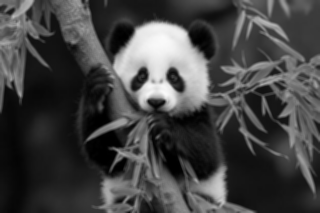

In [11]:
final

In [ ]:
# Display image
final.show() #displays the final filtered image using the show() method of the PIL Image object. This will open the default image viewer on your system to display the processed image.

In [10]:
final.save('images/box.jpg')